# Conservative shell CLM: original vs TSV vs direct Fourier comparison

This notebook is a **notebook-only prototype**. It does not edit either GODMAX source
tree. It compares three matched implementations of the collisionless-matter satellite
window:

1. **Original:** differentiate a piecewise-linear interpolant at its knots, then FFTLog.
2. **TSV:** central `jnp.gradient` of log enclosed mass, then FFTLog.
3. **Shell:** keep finite-volume shell masses and transform them directly, with no density
   derivative, FFTLog, logarithmic amplitude interpolation, or upper clipping.

The shell construction is the cleanest candidate. It conserves every supplied enclosed-mass
node, makes the raw Fourier zero mode exactly one, and reduces the differentiable operation
to a static kernel times shell masses. Its simplest inner continuation uses the physical
NFW cusp, $M(<r)\propto r^2$, inside the first sampled radius. A fitted inner power law is
retained as a diagnostic, not silently imposed.

The result is deliberately narrower than a source change: only the galaxy-satellite
$u_{\rm clm}$ and the resulting $P_{gg}$ are recomputed. DMB, HSE, maps, and pressure remain
unchanged and are explicit null controls. A future source implementation would require
their own shell-aware paths.


## 0. Falsifiable questions

The executable cells test:

1. Does the shell construction reproduce every $M_{\rm clm}(<r_i)$ and raw
   $u_{\rm clm}(0)=1$ without clipping?
2. At matched parameters, what are the original, TSV, and shell **raw** and final
   $u_{\rm clm}$ values?
3. Is $P_{gg}^{\rm backreaction}/P_{gg}^{\rm no\ backreaction}$ one at
   $k\le10^{-2}$ and at the broader invariant range $k<0.1\,h\,{\rm Mpc}^{-1}$?
4. Does the conclusion survive a radial-resolution change?
5. Is the shell calculation x64/JIT/reverse-mode safe, and what are the measured compiled
   memory and steady-state costs relative to the two FFTLog paths?
6. Are source files and all non-CLM outputs left unchanged?

Necessary is not sufficient: normalizing a complete shell sum by $M(<r_{\max})$ makes the
zero mode exact, but physical completeness additionally requires
$M(<r_{\max})\simeq f_{\rm clm}M_{\rm tot}$ and non-negative shell masses. Both are printed.
Re-run all cells before treating displayed output as evidence.


In [1]:
# Configure precision before the first JAX array is created.
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/godmax-mpl')
from jax import config as jax_config
jax_config.update('jax_enable_x64', True)

import copy
import hashlib
import subprocess
import sys
import time
import warnings
from functools import partial
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import yaml

ORIGINAL_ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
TSV_ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX')
ORIGINAL_RADIAL = ORIGINAL_ROOT / 'src/get_radial_profiles.py'
TSV_RADIAL = TSV_ROOT / 'src/godmax/get_radial_profiles.py'
TSV_PK = TSV_ROOT / 'src/godmax/get_Pkzs.py'
assert ORIGINAL_RADIAL.exists() and TSV_RADIAL.exists() and TSV_PK.exists()

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def git_value(root, *args):
    return subprocess.check_output(['git', '-C', str(root), *args], text=True).strip()

source_hashes_before = {str(p): sha256(p) for p in (ORIGINAL_RADIAL, TSV_RADIAL, TSV_PK)}
print('Python:', sys.version.split()[0])
print('JAX/jaxlib:', jax.__version__, jax.lib.__version__)
print('backend/devices:', jax.default_backend(), jax.devices())
print('x64/default dtype:', jax.config.jax_enable_x64, jnp.ones(1).dtype)
print('original:', git_value(ORIGINAL_ROOT, 'rev-parse', '--abbrev-ref', 'HEAD'), git_value(ORIGINAL_ROOT, 'rev-parse', 'HEAD'))
print('TSV:', git_value(TSV_ROOT, 'rev-parse', '--abbrev-ref', 'HEAD'), git_value(TSV_ROOT, 'rev-parse', 'HEAD'))
print('source SHA256 before:', source_hashes_before)


Python: 3.10.16
JAX/jaxlib: 0.5.0 0.5.0
backend/devices: cpu [CpuDevice(id=0)]
x64/default dtype: True float64
original: ltuSP 29c3a2776ace0f9d2d03a04d39967ff1525ca04b


TSV: tsv-dev-debug b876522a469355b273b847e53b7bd4bc359adb37
source SHA256 before: {'/mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/get_radial_profiles.py': 'cb1011f7484426e31a8bce833adc75f9f32ff7138fb23864db55e405d3e5d75f', '/mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/get_radial_profiles.py': '1410d57a282d0469408e1202c1c5b15b93fe809ae7017ac4d5489a38415542dc', '/mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/get_Pkzs.py': 'e5e8b7431e19061e73aafbde666de261b8006f1a04f3d2c93064e9d14d1edd39'}


## 1. Conservative representation and units

For tabulated enclosed mass $M_i=M(<r_i)$, define the represented masses

$$\Delta M_0=M_0,\qquad \Delta M_i=M_i-M_{i-1}\quad(i\ge1).$$

Then $\sum_{j=0}^{i}\Delta M_j=M_i$ algebraically. If a real-space density is needed,
the finite-volume value is

The inner cell is $[0,r_0]$. For $i\ge1$, $\Delta M_i$ belongs to
$[r_{i-1},r_i]$, so

$$\rho_0=\frac{M_0}{(4\pi/3)r_0^3},\qquad
\rho_i=\frac{\Delta M_i}{(4\pi/3)(r_i^3-r_{i-1}^3)}.$$

Here $r$ is comoving Mpc/$h$, $k$ is $h$/Mpc, mass is $M_\odot/h$, density is
$(M_\odot/h)/(\mathrm{Mpc}/h)^3$, the shell window and $u_{\rm clm}$ are dimensionless,
and $P_{gg}$ has units $(\mathrm{Mpc}/h)^3$.

For resolved shells with constant volume density,

$$W_i(k)=\frac{r_{i+1}^3W_{\rm TH}(kr_{i+1})-r_i^3W_{\rm TH}(kr_i)}
{r_{i+1}^3-r_i^3},\quad
W_{\rm TH}(x)=3\frac{\sin x-x\cos x}{x^3}.$$

Inside $r_0$, finite NFW density normalization and finite baryonification displacement give
$\rho\sim r^{-1}$ and therefore $M(<r)\sim r^2$. The analytic normalized inner window is

$$W_{\rm in}^{p=2}(x)=\frac{2(1-\cos x)}{x^2}
=1-\frac{x^2}{12}+\frac{x^4}{360}-\frac{x^6}{20160}+\cdots.$$

This fixed inner rule is cheaper and better physically motivated than fitting a noisy slope.
For diagnosis, an arbitrary positive slope $p$ has

$$W_{\rm in}(x;p)=\sum_{n=0}^{\infty}
\frac{(-1)^n p}{p+2n}\frac{x^{2n}}{(2n+1)!}.$$


In [2]:
def rho_original(r, enclosed_mass):
    '''Original right-segment interpolation-knot derivative for one profile.'''
    log_r = jnp.log(r)
    log_m = jnp.log(jnp.clip(enclosed_mass, 0.0) + 1e-30)
    slope = jax.vmap(jax.grad(lambda x: jnp.interp(x, log_r, log_m)))(log_r)
    return jnp.clip(slope * enclosed_mass / (4.0 * jnp.pi * r**3), 0.0, 1e30)

def rho_tsv(r, enclosed_mass):
    '''TSV central log derivative for one profile.'''
    log_r = jnp.log(r)
    log_m = jnp.log(jnp.clip(enclosed_mass, 0.0) + 1e-30)
    slope = jnp.gradient(log_m, log_r)
    return jnp.clip(slope * enclosed_mass / (4.0 * jnp.pi * r**3), 0.0, 1e30)

def w_tophat(x):
    x2 = x * x
    small = jnp.abs(x) < 1e-2
    # Guard the input of the exact division: jnp.where evaluates both arms.
    x_safe = jnp.where(small, 1.0, x)
    exact = 3.0 * (jnp.sin(x_safe) - x_safe * jnp.cos(x_safe)) / x_safe**3
    series = 1.0 - x2/10.0 + x2**2/280.0 - x2**3/15120.0 + x2**4/1330560.0
    return jnp.where(small, series, exact)

def w_inner_p2(x):
    '''Analytic NFW-cusp inner window, stable at x=0.'''
    x2 = x * x
    small = jnp.abs(x) < 1e-2
    x_safe = jnp.where(small, 1.0, x)
    exact = 2.0 * (1.0 - jnp.cos(x_safe)) / x_safe**2
    series = 1.0 - x2/12.0 + x2**2/360.0 - x2**3/20160.0 + x2**4/1814400.0
    return jnp.where(small, series, exact)

def w_inner_powerlaw(x, p, n_terms=8):
    '''Diagnostic arbitrary-p inner solution; p has shape (...).'''
    x2 = x * x
    broadcast = jnp.ones_like(x + 0.0 * p[None, :, :])
    def body(n, state):
        term, total = state
        nf = jnp.asarray(n, dtype=x.dtype)
        term = -term * x2 / ((2.0*nf) * (2.0*nf + 1.0))
        total = total + term * p[None, :, :] / (p[None, :, :] + 2.0*nf)
        return term, total
    return jax.lax.fori_loop(1, n_terms, body, (broadcast, broadcast))[1]

def shell_window(k, rin, rout):
    '''Exact constant-density shell window plus a cancellation-safe low-k series.'''
    kcol = k[:, None]
    den = rout**3 - rin**3
    exact = (
        rout[None, :]**3 * w_tophat(kcol*rout[None, :])
        - rin[None, :]**3 * w_tophat(kcol*rin[None, :])
    ) / den[None, :]
    k2 = kcol**2
    series = (
        1.0
        - k2/10.0 * ((rout**5-rin**5)/den)[None, :]
        + k2**2/280.0 * ((rout**7-rin**7)/den)[None, :]
        - k2**3/15120.0 * ((rout**9-rin**9)/den)[None, :]
    )
    return jnp.where(jnp.abs(kcol*rout[None, :]) < 1e-2, series, exact)

def fitted_inner_slope(r, enclosed_mass):
    return (
        jnp.log(enclosed_mass[1]) - jnp.log(enclosed_mass[0])
    ) / (jnp.log(r[1]) - jnp.log(r[0]))

def shell_masses(enclosed_mass):
    return jnp.concatenate((enclosed_mass[:1], jnp.diff(enclosed_mass, axis=0)), axis=0)

def shell_u(k, r, enclosed_mass, inner='p2'):
    '''Direct Fourier transform; radial axis is first and batching is native.'''
    dm = shell_masses(enclosed_mass)
    outer = shell_window(k, r[:-1], r[1:])
    x0 = k[:, None, None] * r[0]
    pfit = fitted_inner_slope(r, enclosed_mass)
    if inner == 'p2':
        win = w_inner_p2(x0)
    elif inner == 'pfit':
        win = w_inner_powerlaw(x0, pfit)
    elif inner == 'uniform':
        win = w_tophat(x0)
    elif inner == 'point':
        win = jnp.ones_like(x0)
    elif inner == 'omit':
        win = jnp.zeros_like(x0)
    else:
        raise ValueError(inner)
    fourier_mass = enclosed_mass[0][None, :, :] * win
    fourier_mass = fourier_mass + jnp.einsum('ks,szm->kzm', outer, dm[1:])
    endpoint = enclosed_mass[-1]
    endpoint_safe = jnp.where(endpoint > 0.0, endpoint, 1.0)
    return fourier_mass / endpoint_safe[None, :, :], dm, pfit


### Analytic controls

The following tests do not use GODMAX. They establish the two identities independently:
shell masses telescope at every node, and the short inner series agrees with direct
quadrature for $kr_0\le0.75$. No normalization or clipping is used to make these pass.


In [3]:
r_syn = jnp.geomspace(0.005, 48.0, 23)
M_syn = 3e14 * (r_syn/0.7)**1.7 / (1.0 + (r_syn/0.7)**1.7)
dm_syn = shell_masses(M_syn[:, None, None])[:, 0, 0]
node_error = jnp.max(jnp.abs(jnp.cumsum(dm_syn)/M_syn - 1.0))

xs = jnp.linspace(0.0, 0.75, 21)
# With y=t^p, p*integral t^(p-1)sinc(xt)dt = integral sinc(x*y^(1/p))dy.
# This removes the weak t=0 endpoint singularity from the quadrature control.
ys = jnp.linspace(0.0, 1.0, 50000)
inner_errors = []
for p in (1.3, 2.0, 3.0):
    pp = jnp.array([[p]])
    series = w_inner_powerlaw(xs[:, None, None], pp)[:, 0, 0]
    dense = jax.vmap(lambda x: jnp.trapezoid(jnp.sinc(x*ys**(1.0/p)/jnp.pi), x=ys))(xs)
    inner_errors.append(float(jnp.max(jnp.abs(series-dense))))

p2_closed = w_inner_p2(xs)
p2_series = w_inner_powerlaw(xs[:, None, None], jnp.array([[2.0]]))[:, 0, 0]

# Independent high-k sign/value check for one resolved constant-density shell.
k_shell = jnp.linspace(0.0, 150.0, 51)
rin_test, rout_test = 0.3, 0.9
r_dense = jnp.linspace(rin_test, rout_test, 100000)
shell_closed = shell_window(k_shell, jnp.array([rin_test]), jnp.array([rout_test]))[:, 0]
shell_dense = jax.vmap(
    lambda kval: 3.0*jnp.trapezoid(
        r_dense**2*jnp.sinc(kval*r_dense/jnp.pi), x=r_dense
    )/(rout_test**3-rin_test**3)
)(k_shell)
print('max cumulative-node relative error:', float(node_error))
print('inner series vs dense quadrature max errors for p=1.3,2,3:', inner_errors)
print('p=2 closed form vs general series max error:', float(jnp.max(jnp.abs(p2_closed-p2_series))))
print('p=2 inner window at kr0=0.75:', float(w_inner_p2(jnp.array(0.75))))
print('resolved-shell closed form vs dense high-k quadrature max error:',
      float(jnp.max(jnp.abs(shell_closed-shell_dense))))
print('resolved-shell closed/dense min-max:',
      (float(shell_closed.min()), float(shell_closed.max())),
      (float(shell_dense.min()), float(shell_dense.max())))
assert float(node_error) < 1e-12
assert max(inner_errors) < 1e-8


max cumulative-node relative error: 2.220446049250313e-16
inner series vs dense quadrature max errors for p=1.3,2,3: [4.540257059204578e-12, 1.723066134218243e-13, 2.124438402972828e-10]
p=2 closed form vs general series max error: 5.917488721252084e-14
p=2 inner window at kr0=0.75: 0.9539951328930812
resolved-shell closed form vs dense high-k quadrature max error: 1.538502658604557e-11
resolved-shell closed/dense min-max: (-0.11045658078054697, 1.0) (-0.11045658077608168, 1.000000000015385)


## 2. Matched GODMAX experiment

Raw branch defaults are not compared: they change ejection parameters, mass range,
split-CGA behavior and tSZ. Instead, all three implementations run inside the same TSV
pipeline and configuration. The original source method is reproduced verbatim as an
in-memory monkeypatch and restored in `finally`. This isolates the CLM numerical method.

The reduced grid uses two redshifts and six halo masses for an inexpensive causal test.
The full TSV mass range is retained, and $r_{\max}=48$ Mpc/$h$ reduces known ejected-profile
undercoverage. Endpoint/target coverage is still reported rather than assumed.


In [4]:
sys.path.insert(0, str(TSV_ROOT / 'src'))
import godmax.get_radial_profiles as tsv_radial
from godmax.get_Pkzs import get_Pkz as TSVPk
from godmax.mcfitjax.cosmology_jax import xi2P

cfg = yaml.safe_load((TSV_ROOT / 'param_files/params_default.yaml').read_text())
base_sim = copy.deepcopy(cfg['sim_params'])
base_halo = copy.deepcopy(cfg['halo_params'])
base_analysis = copy.deepcopy(cfg['analysis'])
base_other = copy.deepcopy(cfg['other_params'])
base_halo.update(nz=2, nM=6, nr=23, nk=32, lg10_Mmin=10.5, lg10_Mmax=16.5,
                 rmin=0.005, rmax=48.0)
base_analysis.update(model_tSZ=True, model_galaxies=True, verbose_time=False,
                     nbar_gal_comoving_val=5.0e-4, split_cga_fftlog=False,
                     symbolic_hmf=True, symbolic_pk=True, baryonification_tSZ=True,
                     gg_transition_model='poweradd')

central_method = tsv_radial.Profiles.get_rho_clm

@partial(jax.jit, static_argnums=(0,))
def original_method(self, jz, jM, r_array_here=None):
    if r_array_here is None:
        r_here = self.r_array
        M_here = self.Mclm_mat[:, jz, jM]
    else:
        r_here = r_array_here
        M_here = jnp.exp(jnp.interp(jnp.log(r_here), jnp.log(self.r_array),
                                     jnp.log(self.Mclm_mat[:, jz, jM])))
    log_r = jnp.log(r_here)
    log_m = jnp.log(jnp.clip(M_here, 0.0) + 1e-30)
    slope = jax.vmap(jax.grad(lambda x: jnp.interp(x, log_r, log_m)))(log_r)
    return jnp.clip(slope*M_here/(4.0*jnp.pi*r_here**3), 0.0, 1e30)

def build_pk(nr, backreaction, method):
    h = copy.deepcopy(base_halo)
    h['nr'] = nr
    a = copy.deepcopy(base_analysis)
    a['backreaction'] = backreaction
    previous = tsv_radial.Profiles.get_rho_clm
    try:
        tsv_radial.Profiles.get_rho_clm = method
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            obj = TSVPk(copy.deepcopy(base_sim), h, a, copy.deepcopy(base_other))
        return obj, [str(w.message) for w in caught]
    finally:
        tsv_radial.Profiles.get_rho_clm = previous

def matched_models(nr):
    # The no-backreaction branch uses analytic f_clm*rho_NFW, so the derivative is irrelevant.
    no, warn_no = build_pk(nr, False, central_method)
    old, warn_old = build_pk(nr, True, original_method)
    tsv, warn_tsv = build_pk(nr, True, central_method)
    return no, old, tsv, warn_no + warn_old + warn_tsv

p_no, p_old, p_tsv, coverage_warnings = matched_models(23)
non_clm_snapshot = {
    'Pmm_tot': np.asarray(p_tsv.Pmm_tot_mat).copy(),
    'phfit': np.asarray(p_tsv.phfit_kz_mat).copy(),
    'Pyy': np.asarray(p_tsv.Pyy_tot_kz_mat).copy(),
}
print('grid nr,nz,nM,nk:', p_tsv.nr, p_tsv.nz, p_tsv.nM, p_tsv.nk)
print('r range [Mpc/h]:', float(p_tsv.r_array[0]), float(p_tsv.r_array[-1]))
print('k range [h/Mpc]:', float(p_tsv.kPk_array[0]), float(p_tsv.kPk_array[-1]))
print('coverage warnings:', coverage_warnings)
print('Mclm equality old/TSV max relative:', float(jnp.max(jnp.abs(p_old.Mclm_mat/p_tsv.Mclm_mat-1.0))))


grid nr,nz,nM,nk: 23 2 6 32
r range [Mpc/h]: 0.0050000000000000044 47.99999999999997
k range [h/Mpc]: 0.00010000000000000021 149.9999999999999
coverage warnings: []
Mclm equality old/TSV max relative: 0.0


### Mass closure and physical validity

The FFTLog methods first reconstruct nodal density and later integrate it. The shell method
never performs that round trip. Its cumulative-node error should be roundoff. Negative
$\Delta M$ values are reported, not clipped: even exact global conservation does not make a
non-monotonic profile physical.


In [5]:
r23 = p_tsv.r_array
M23 = p_tsv.Mclm_mat
pref = 4.0*jnp.pi*r23[:, None, None]**2
delta_endpoint = M23[-1] - M23[0]
old_closure = jnp.trapezoid(pref*p_old.rho_clm_mat, x=r23, axis=0)/delta_endpoint
tsv_closure = jnp.trapezoid(pref*p_tsv.rho_clm_mat, x=r23, axis=0)/delta_endpoint
dm23 = shell_masses(M23)
shell_node_error = jnp.max(jnp.abs(jnp.cumsum(dm23, axis=0)/M23-1.0))
pfit23 = fitted_inner_slope(r23, M23)
inner_fraction = M23[0]/M23[-1]
endpoint_target = M23[-1]/(p_tsv.fclm_mat*p_tsv.Mtot_mat)
negative_outer = dm23[1:] < 0
min_dm_fraction = jnp.min(dm23[1:]/M23[-1][None, :, :])

def stats(x):
    return tuple(float(q) for q in (jnp.min(x), jnp.median(x), jnp.max(x), jnp.max(jnp.abs(x-1.0))))

print('original density-integral ratio min/median/max/max|err|:', stats(old_closure))
print('TSV density-integral ratio min/median/max/max|err|:', stats(tsv_closure))
print('shell cumulative-node max relative error:', float(shell_node_error))
print('negative outer shell count / min DeltaM/Mend:', int(jnp.sum(negative_outer)), float(min_dm_fraction))
print('inner M(r0)/Mend min/median/max:', *(float(x) for x in (inner_fraction.min(), jnp.median(inner_fraction), inner_fraction.max())))
print('fitted inner p min/median/max:', *(float(x) for x in (pfit23.min(), jnp.median(pfit23), pfit23.max())))
print('endpoint/(fclm*Mtot) min/median/max:', *(float(x) for x in (endpoint_target.min(), jnp.median(endpoint_target), endpoint_target.max())))
assert float(shell_node_error) < 1e-12


original density-integral ratio min/median/max/max|err|: (0.8652232014298675, 0.8722599922365151, 0.8866697202429127, 0.13477679857013247)
TSV density-integral ratio min/median/max/max|err|: (1.0361909622796124, 1.0412389222630032, 1.042245071626028, 0.042245071626028086)
shell cumulative-node max relative error: 2.220446049250313e-16
negative outer shell count / min DeltaM/Mend: 14 -1.1616318039500731e-06
inner M(r0)/Mend min/median/max: 1.0296897520613027e-06 0.0005476049299034143 0.05590002368852499
fitted inner p min/median/max: 1.3754742814446177 1.8407464675223362 2.0111714399850014
endpoint/(fclm*Mtot) min/median/max: 0.9767205477422007 1.0010784018966152 1.0014850739060368


## 3. Final $u_{\rm clm}$: pipeline output and raw pre-clip output

The stored original/TSV `uk_clm` is the final pipeline quantity: raw FFTLog output is
clipped to $[10^{-30},1]$ and log-interpolated. To expose that confounder, the same raw
FFTLog arrays are also interpolated linearly in signed amplitude versus $\ln k$, with no
clip. The shell result is already evaluated on the target $k$ grid and is never clipped.
Signed interpolation is important because a valid spherical Fourier profile may cross zero.


original pipeline first-k min/median/max: 0.8412057304756988 0.8626991780761943 1.0
TSV pipeline first-k min/median/max: 1.0 1.0 1.0
original raw first-k min/median/max: 0.8412057304756988 0.8626991780761943 1.2017512146087963
TSV raw first-k min/median/max: 1.0109080382856301 1.0197303188023632 1.3261730914098984
shell raw first-k min/median/max: 0.9999995729001913 0.9999999960654857 0.9999999999874739
shell explicit k=0 max |u-1|: 2.220446049250313e-16
shell all-k min/max: 2.4789277462776103e-07 0.9999999999874739
low-k curvature max relative error: 4.633526275110711e-06


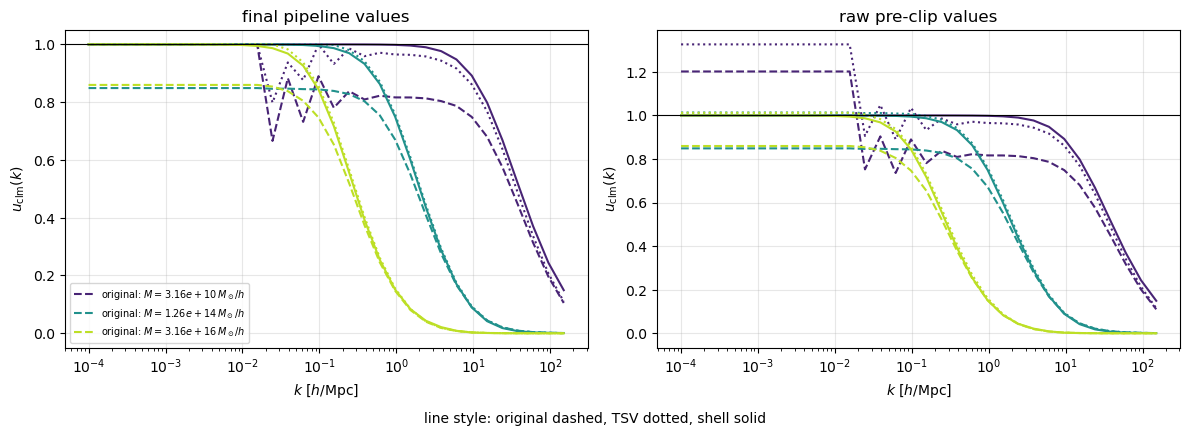

In [6]:
def signed_logk_interp(k_target, k_source, values):
    flat = values.reshape((values.shape[0], -1))
    out = jax.vmap(
        lambda y: jnp.interp(jnp.log(k_target), jnp.log(k_source), y),
        in_axes=1, out_axes=1,
    )(flat)
    return out.reshape((k_target.size,) + values.shape[1:])

k23 = p_tsv.kPk_array
u_old_pipeline = p_old.uk_clm
u_tsv_pipeline = p_tsv.uk_clm
u_no_pipeline = p_no.uk_clm
u_old_raw = signed_logk_interp(k23, p_old.k_mcfit, p_old.uk_clm_tointp)
u_tsv_raw = signed_logk_interp(k23, p_tsv.k_mcfit, p_tsv.uk_clm_tointp)
u_no_raw = signed_logk_interp(k23, p_no.k_mcfit, p_no.uk_clm_tointp)
u_shell, dm_shell, pfit_shell = shell_u(k23, r23, M23, inner='p2')
u_shell_no = shell_u(k23, p_no.r_array, p_no.Mclm_mat, inner='p2')[0]
u_shell_zero = shell_u(jnp.array([0.0]), r23, M23, inner='p2')[0]

# Independent low-k moment: u(k)=1-k^2<r^2>/6+O(k^4).
outer_dm = dm_shell[1:]
rin, rout = r23[:-1], r23[1:]
outer_r2 = (3.0/5.0)*(rout**5-rin**5)/(rout**3-rin**3)
mean_r2 = (
    M23[0]*(0.5*r23[0]**2)
    + jnp.einsum('s,szm->zm', outer_r2, outer_dm)
)/M23[-1]
curvature_measured = (1.0-u_shell[0])/(k23[0]**2)
curvature_predicted = mean_r2/6.0

def low_stats(name, u):
    x = u[0]
    print(name, 'first-k min/median/max:', float(x.min()), float(jnp.median(x)), float(x.max()))

for name, value in (
    ('original pipeline', u_old_pipeline), ('TSV pipeline', u_tsv_pipeline),
    ('original raw', u_old_raw), ('TSV raw', u_tsv_raw), ('shell raw', u_shell),
):
    low_stats(name, value)
print('shell explicit k=0 max |u-1|:', float(jnp.max(jnp.abs(u_shell_zero-1.0))))
print('shell all-k min/max:', float(u_shell.min()), float(u_shell.max()))
print('low-k curvature max relative error:',
      float(jnp.max(jnp.abs(curvature_measured/curvature_predicted-1.0))))

mass_indices = [0, p_tsv.nM//2, p_tsv.nM-1]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(mass_indices)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for c, jm in zip(colors, mass_indices):
    label = rf'$M={float(p_tsv.M_array[jm]):.2e}\,M_\odot/h$'
    axes[0].semilogx(k23, np.asarray(u_old_pipeline[:, 0, jm]), '--', color=c, label='original: '+label)
    axes[0].semilogx(k23, np.asarray(u_tsv_pipeline[:, 0, jm]), ':', color=c)
    axes[0].semilogx(k23, np.asarray(u_shell[:, 0, jm]), '-', color=c)
    axes[1].semilogx(k23, np.asarray(u_old_raw[:, 0, jm]), '--', color=c)
    axes[1].semilogx(k23, np.asarray(u_tsv_raw[:, 0, jm]), ':', color=c)
    axes[1].semilogx(k23, np.asarray(u_shell[:, 0, jm]), '-', color=c)
for ax, title in zip(axes, ('final pipeline values', 'raw pre-clip values')):
    ax.axhline(1.0, color='k', lw=.8)
    ax.set(xlabel='$k$ [$h$/Mpc]', ylabel='$u_{\\rm clm}(k)$', title=title)
    ax.grid(alpha=.3)
axes[0].legend(fontsize=7)
fig.text(.5, -.02, 'line style: original dashed, TSV dotted, shell solid', ha='center')
plt.tight_layout(); plt.show()


## 4. Propagate only $u_{\rm clm}$ into galaxy power

This pure function reproduces the TSV HOD, mass integration, and configured 1h--2h
combination without mutating the object. First, feeding the object's own `uk_clm` back into
the function must reproduce stored $P_{gg}$ to roundoff. Then raw original, raw TSV, and
shell windows are compared against method-matched no-backreaction references.

Both $P_{gg}^{2h}$ and total $P_{gg}$ are shown. Reporting only the two-halo term could hide
a low-$k$ one-halo difference; reporting only total power could hide the bias mechanism.


stored-Pgg replay max relative error old P2/Ptot: 4.440892098500626e-16 3.3306690738754696e-16
stored-Pgg replay max relative error TSV P2/Ptot: 6.661338147750939e-16 5.551115123125783e-16
method                P2 k<=.01      P2 k<.1    Ptot k<=.01    Ptot k<.1


original pipeline      0.071108    0.0720828       0.130222     0.130222
TSV pipeline        2.17505e-05   0.00212986    9.64305e-05   0.00243321
original raw          0.0719502    0.0723331       0.131358     0.131358
TSV raw              0.00588599   0.00588599      0.0109126    0.0109126
shell raw           6.13536e-07  5.94614e-05    6.52324e-07   7.3448e-05


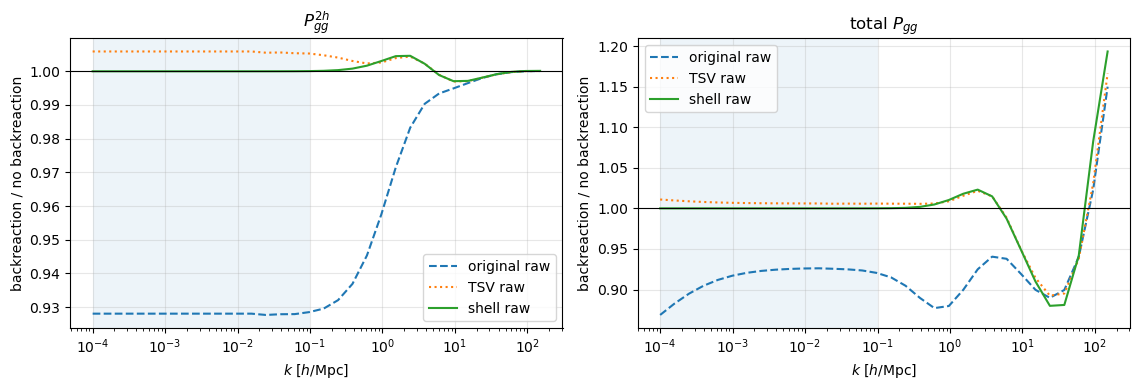

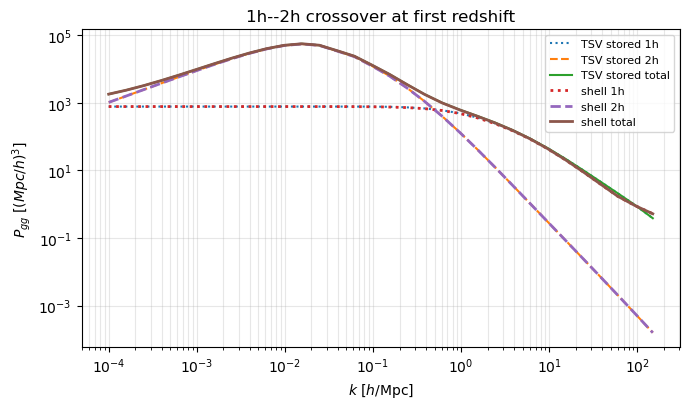

In [7]:
def pgg_from_u(obj, u):
    nbar = obj.nbarz[None, :, None]
    ukg_cross = jnp.maximum(
        (obj.Ncen_mat[None] + obj.Nsat_mat[None]*u)/nbar,
        1e-10,
    )
    ukg_auto = jnp.maximum(
        jnp.nan_to_num(
            2.0*obj.Ncen_mat[None]*obj.Nsat_mat[None]*u
            + (obj.Nsat_mat[None]*u)**2,
            nan=0.0, posinf=0.0, neginf=0.0,
        ),
        1e-10,
    )/nbar**2
    log_mass = jnp.log(obj.M_array)
    bg = jnp.trapezoid(
        ukg_cross*obj.hmf_Mz_mat[None]*obj.bias_Mz_mat[None],
        x=log_mass, axis=-1,
    )
    p2 = bg**2*obj.plin_kz_mat
    p1 = jnp.trapezoid(ukg_auto*obj.hmf_Mz_mat[None], x=log_mass, axis=-1)
    total = obj._combine_1h2h_poweradd(p1, p2, obj.alpha_gg)
    if obj.gg_transition_model == 'response':
        total = (p1+p2)*obj.Pmm_sup_tot_mat
    return {'P1h': p1, 'P2h': p2, 'Ptot': total, 'bg': bg}

replay_old = pgg_from_u(p_old, p_old.uk_clm)
replay_tsv = pgg_from_u(p_tsv, p_tsv.uk_clm)
print('stored-Pgg replay max relative error old P2/Ptot:',
      float(jnp.max(jnp.abs(replay_old['P2h']/p_old.Pgg_2h_kz_mat-1))),
      float(jnp.max(jnp.abs(replay_old['Ptot']/p_old.Pgg_tot_mat-1))))
print('stored-Pgg replay max relative error TSV P2/Ptot:',
      float(jnp.max(jnp.abs(replay_tsv['P2h']/p_tsv.Pgg_2h_kz_mat-1))),
      float(jnp.max(jnp.abs(replay_tsv['Ptot']/p_tsv.Pgg_tot_mat-1))))

raw_no = pgg_from_u(p_no, u_no_raw)
raw_old = pgg_from_u(p_old, u_old_raw)
raw_tsv = pgg_from_u(p_tsv, u_tsv_raw)
shell_no = pgg_from_u(p_no, u_shell_no)
shell_back = pgg_from_u(p_tsv, u_shell)

ratios = {
    'original pipeline': {
        'P2h': p_old.Pgg_2h_kz_mat/p_no.Pgg_2h_kz_mat,
        'Ptot': p_old.Pgg_tot_mat/p_no.Pgg_tot_mat,
    },
    'TSV pipeline': {
        'P2h': p_tsv.Pgg_2h_kz_mat/p_no.Pgg_2h_kz_mat,
        'Ptot': p_tsv.Pgg_tot_mat/p_no.Pgg_tot_mat,
    },
    'original raw': {q: raw_old[q]/raw_no[q] for q in ('P2h', 'Ptot')},
    'TSV raw': {q: raw_tsv[q]/raw_no[q] for q in ('P2h', 'Ptot')},
    'shell raw': {q: shell_back[q]/shell_no[q] for q in ('P2h', 'Ptot')},
}

def maxdev(x, mask):
    return float(jnp.max(jnp.abs(x[mask]-1.0)))

print(f"{'method':18s} {'P2 k<=.01':>12s} {'P2 k<.1':>12s} {'Ptot k<=.01':>14s} {'Ptot k<.1':>12s}")
for name, d in ratios.items():
    print(f"{name:18s} {maxdev(d['P2h'], k23<=1e-2):12.6g} {maxdev(d['P2h'], k23<.1):12.6g} "
          f"{maxdev(d['Ptot'], k23<=1e-2):14.6g} {maxdev(d['Ptot'], k23<.1):12.6g}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
styles = {'original raw':'--', 'TSV raw':':', 'shell raw':'-'}
for name, style in styles.items():
    axes[0].semilogx(k23, np.asarray(ratios[name]['P2h'][:, 0]), style, label=name)
    axes[1].semilogx(k23, np.asarray(ratios[name]['Ptot'][:, 0]), style, label=name)
for ax, title in zip(axes, ('$P_{gg}^{2h}$', 'total $P_{gg}$')):
    ax.axhline(1.0, color='k', lw=.8)
    ax.axvspan(float(k23[0]), 0.1, alpha=.08)
    ax.set(xlabel='$k$ [$h$/Mpc]', ylabel='backreaction / no backreaction', title=title)
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.loglog(k23, np.asarray(p_tsv.Pgg_1h_kz_mat[:, 0]), ':', label='TSV stored 1h')
ax.loglog(k23, np.asarray(p_tsv.Pgg_2h_kz_mat[:, 0]), '--', label='TSV stored 2h')
ax.loglog(k23, np.asarray(p_tsv.Pgg_tot_mat[:, 0]), '-', label='TSV stored total')
ax.loglog(k23, np.asarray(shell_back['P1h'][:, 0]), ':', lw=2, label='shell 1h')
ax.loglog(k23, np.asarray(shell_back['P2h'][:, 0]), '--', lw=2, label='shell 2h')
ax.loglog(k23, np.asarray(shell_back['Ptot'][:, 0]), '-', lw=2, label='shell total')
ax.set(xlabel='$k$ [$h$/Mpc]', ylabel='$P_{gg}$ [$(Mpc/h)^3$]',
       title='1h--2h crossover at first redshift')
ax.grid(alpha=.3, which='both'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### Inner-cell alternatives

Omitting $M(<r_0)$ is not conservative. A point mass preserves the monopole but assumes an
unresolved delta function; a uniform inner sphere assumes $p=3$. The fixed $p=2$ window
uses the known NFW cusp. The fitted-$p$ result is a diagnostic for whether $r_0$ has reached
that asymptote. None of these variants clips a slope or shell mass.


largest inner-mass halo (jz,jM), fraction: (0, 0) 0.05590002368852499
kmax*r0: 0.7500000000000001
pfit range and all-valid flag: 1.3754742814446177 2.0111714399850014 True
omit explicit/finite first-k value at focus: 0.944099976311475 0.94409997629895
point explicit/finite first-k value at focus: 1.0 0.999999999987475
uniform explicit/finite first-k value at focus: 1.0 0.9999999999874737
p2 explicit/finite first-k value at focus: 1.0 0.9999999999874739
pfit explicit/finite first-k value at focus: 1.0 0.999999999987474


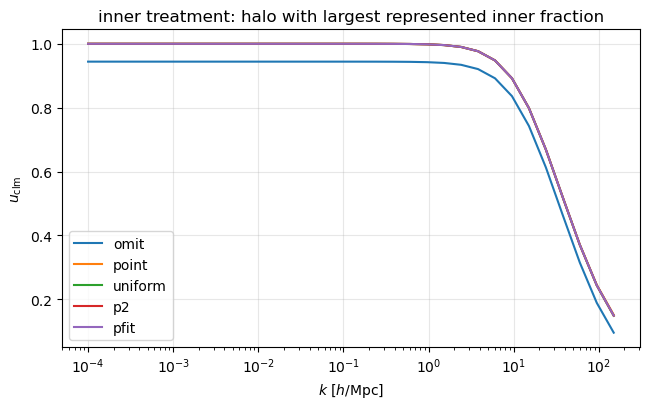

In [8]:
inner_variants = {
    name: shell_u(k23, r23, M23, inner=name)[0]
    for name in ('omit', 'point', 'uniform', 'p2', 'pfit')
}
jz_focus, jM_focus = np.unravel_index(int(jnp.argmax(inner_fraction)), inner_fraction.shape)
print('largest inner-mass halo (jz,jM), fraction:', (jz_focus, jM_focus), float(inner_fraction[jz_focus, jM_focus]))
print('kmax*r0:', float(k23[-1]*r23[0]))
print('pfit range and all-valid flag:', float(pfit23.min()), float(pfit23.max()), bool(jnp.all(jnp.isfinite(pfit23) & (pfit23 > 0))))
for name, u in inner_variants.items():
    print(name, 'explicit/finite first-k value at focus:',
          float(shell_u(jnp.array([0.0]), r23, M23, inner=name)[0][0, jz_focus, jM_focus]),
          float(u[0, jz_focus, jM_focus]))

fig, ax = plt.subplots(figsize=(6.6, 4.2))
for name, u in inner_variants.items():
    ax.semilogx(k23, np.asarray(u[:, jz_focus, jM_focus]), label=name)
ax.set(xlabel='$k$ [$h$/Mpc]', ylabel='$u_{\\rm clm}$', title='inner treatment: halo with largest represented inner fraction')
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()


## 5. Radial-resolution test

Repeat the complete matched construction at $n_r=47$. The higher-resolution shell result
is used as a numerical reference, not declared exact. This test separates an analytic
inner correction from errors in the remaining coarse piecewise-constant outer shells.


In [9]:
q_no, q_old, q_tsv, warnings47 = matched_models(47)
k47 = q_tsv.kPk_array
q_old_raw = signed_logk_interp(k47, q_old.k_mcfit, q_old.uk_clm_tointp)
q_tsv_raw = signed_logk_interp(k47, q_tsv.k_mcfit, q_tsv.uk_clm_tointp)
q_no_raw = signed_logk_interp(k47, q_no.k_mcfit, q_no.uk_clm_tointp)
q_shell = shell_u(k47, q_tsv.r_array, q_tsv.Mclm_mat, inner='p2')[0]
q_shell_no = shell_u(k47, q_no.r_array, q_no.Mclm_mat, inner='p2')[0]

q_raw_old = pgg_from_u(q_old, q_old_raw); q_raw_tsv = pgg_from_u(q_tsv, q_tsv_raw)
q_raw_no = pgg_from_u(q_no, q_no_raw)
q_shell_back = pgg_from_u(q_tsv, q_shell); q_shell_ref = pgg_from_u(q_no, q_shell_no)

rows = []
for nr, kval, old_obj, tsv_obj, no_obj, ro, rt, rn, sb, sn in (
    (23, k23, p_old, p_tsv, p_no, raw_old, raw_tsv, raw_no, shell_back, shell_no),
    (47, k47, q_old, q_tsv, q_no, q_raw_old, q_raw_tsv, q_raw_no, q_shell_back, q_shell_ref),
):
    low = kval <= 1e-2
    rows.append((nr,
        maxdev(old_obj.Pgg_2h_kz_mat/no_obj.Pgg_2h_kz_mat, low),
        maxdev(tsv_obj.Pgg_2h_kz_mat/no_obj.Pgg_2h_kz_mat, low),
        maxdev(ro['P2h']/rn['P2h'], low),
        maxdev(rt['P2h']/rn['P2h'], low),
        maxdev(sb['P2h']/sn['P2h'], low)))
print(f"{'nr':>4s} {'old pipe':>12s} {'TSV pipe':>12s} {'old raw':>12s} {'TSV raw':>12s} {'shell raw':>12s}")
for row in rows:
    print(f'{row[0]:4d}' + ''.join(f'{x:12.6g}' for x in row[1:]))

u23_p2 = inner_variants['p2']
u23_pfit = inner_variants['pfit']
u23_point = inner_variants['point']
u23_uniform = inner_variants['uniform']
u23_omit = inner_variants['omit']
print('max |u_nr23 - u_nr47,p2| all k:')
for name, value in [('omit',u23_omit), ('point',u23_point), ('uniform',u23_uniform), ('p2',u23_p2), ('pfit',u23_pfit)]:
    print(name, float(jnp.max(jnp.abs(value-q_shell))))
print('nr47 shell explicit k=0 max |u-1|:',
      float(jnp.max(jnp.abs(shell_u(jnp.array([0.0]), q_tsv.r_array, q_tsv.Mclm_mat, inner='p2')[0]-1))))


  nr     old pipe     TSV pipe      old raw      TSV raw    shell raw
  23    0.071108 2.17505e-05   0.0719502  0.00588599 6.13536e-07
  47   0.0362937 8.25616e-05   0.0362937  0.00126257 5.51568e-07
max |u_nr23 - u_nr47,p2| all k:
omit 0.06717819091454258
point 0.014049347878533514
uniform 0.014049347878557938
p2 0.01404934787855383
pfit 0.014049347878553053


nr47 shell explicit k=0 max |u-1|: 2.220446049250313e-16


**Resolution interpretation.** The shell large-scale Pgg result is stable between the two
radial grids, while the all-k shell window still moves at the percent level. The fixed
$p=2$, fitted-$p$, point, and uniform inner variants have nearly identical maximum
$n_r=23$ versus $47$ differences: resolved outer shells dominate that statistic. Thus the
analytic inner rule is selected from the NFW cusp limit, not because it was tuned to win
this finite-grid comparison. Omitting the inner mass is clearly worse and even fails the
explicit zero mode. Coarse radial grids are sufficient for the tested large-scale Pgg
question, but not yet demonstrated sufficient for precision nonlinear CLM work.

The analytic cell carries the **represented** $M(r_0)$. TSV's `get_Mnfw` starts its
numerical integral at a finite `minr`, so this notebook does not infer any mass already
omitted upstream below that integration bound. Likewise, exact normalization by
$M(r_{max})$ does not repair outer undercoverage; the printed endpoint/target ratio is the
separate physical check.


## 6. JAX gradients and measured memory

The main $p=2$ shell kernel depends only on the fixed $k$ and $r$ grids. In production it
can be precomputed outside the likelihood; the traced operation is then

```python
dm = concatenate([M[:1], diff(M)])
u = einsum('ks,szm->kzm', W_static, dm) / M[-1]
```

This is one batched contraction with a transpose contraction as its reverse pass. The test
below compares complete *final target-grid* transformations: original derivative+FFTLog,
TSV derivative+FFTLog, and shell contraction. Compile time and steady CPU time are separated.
Compiler memory is backend-dependent and is reported rather than assumed; this host has no
GPU, so GPU throughput remains unverified.


In [10]:
# Make the complete p=2 kernel static, including the analytic inner column.
W_static = jnp.concatenate((w_inner_p2(k23[:, None]*r23[0]),
                            shell_window(k23, r23[:-1], r23[1:])), axis=1)

def shell_static_transform(M):
    dm = shell_masses(M)
    endpoint_safe = jnp.where(M[-1] > 0.0, M[-1], 1.0)
    return jnp.einsum('ks,szm->kzm', W_static, dm)/endpoint_safe[None, :, :]

xi23 = xi2P(r23, nx=p_tsv.nr, lowring=True)

def rho_batch(operator, M):
    flat = M.reshape((M.shape[0], -1))
    rho = jax.vmap(lambda m: operator(r23, m), in_axes=1, out_axes=1)(flat)
    return rho.reshape(M.shape)

def fftlog_transform(operator, M):
    rho = rho_batch(operator, M)
    _, raw = xi23(rho/jnp.where(M[-1] > 0.0, M[-1], 1.0)[None, :, :], axis=0, extrap=False)
    return signed_logk_interp(k23, p_tsv.k_mcfit, raw)

end_to_end = {
    'original+FFTLog': lambda M: fftlog_transform(rho_original, M),
    'TSV+FFTLog': lambda M: fftlog_transform(rho_tsv, M),
    'shell static': shell_static_transform,
}

def memory_fields(compiled):
    info = compiled.memory_analysis()
    names = ('argument_size_in_bytes', 'output_size_in_bytes', 'temp_size_in_bytes',
             'generated_code_size_in_bytes')
    return {name: getattr(info, name, None) for name in names}

def compile_and_time(fn, arg, repeats=20):
    t0 = time.perf_counter()
    compiled = jax.jit(fn).lower(arg).compile()
    compile_s = time.perf_counter()-t0
    compiled(arg).block_until_ready()
    samples = []
    for _ in range(repeats):
        t1 = time.perf_counter(); compiled(arg).block_until_ready(); samples.append(time.perf_counter()-t1)
    return compiled, compile_s, float(np.median(samples))

perf = {}
for name, fn in end_to_end.items():
    compiled, compile_s, steady_s = compile_and_time(fn, M23)
    perf[name] = (compile_s, steady_s, memory_fields(compiled))
    print(name, 'compile_s', compile_s, 'steady_median_s', steady_s, 'memory', perf[name][2])

# Shape-changing synthetic parameter: test reverse-mode against a central parameter difference.
shape = jnp.linspace(-0.2, 0.2, M23.shape[0])[:, None, None]
weights = jnp.linspace(0.3, 1.0, k23.size)[:, None, None]
def shell_objective(theta):
    M = M23*jnp.exp(theta*shape)
    return jnp.mean(shell_static_transform(M)*weights)

theta0 = jnp.array(0.0)
grad_ad = jax.grad(shell_objective)(theta0)
eps = 1e-5
grad_fd = (shell_objective(theta0+eps)-shell_objective(theta0-eps))/(2*eps)
hlo = jax.jit(shell_static_transform).lower(M23).compiler_ir(dialect='hlo').as_hlo_text().lower()
print('shell reverse grad / finite difference / relative error:',
      float(grad_ad), float(grad_fd), float(jnp.abs((grad_ad-grad_fd)/grad_fd)))
print('all shell values/grad finite:', bool(jnp.all(jnp.isfinite(u_shell))), bool(jnp.isfinite(grad_ad)))
print('HLO mentions host callback:', 'host_callback' in hlo or 'outside_compilation' in hlo)
print('static kernel/dynamic shell mass/final u bytes:', W_static.nbytes, dm_shell.nbytes, u_shell.nbytes)
assert bool(jnp.isfinite(grad_ad))


original+FFTLog compile_s 0.1325192099902779 steady_median_s 3.288951120339334e-05 memory {'argument_size_in_bytes': 2208, 'output_size_in_bytes': 3072, 'temp_size_in_bytes': 12608, 'generated_code_size_in_bytes': 0}
TSV+FFTLog compile_s 0.08830389499780722 steady_median_s 0.00012672900629695505 memory {'argument_size_in_bytes': 2208, 'output_size_in_bytes': 3072, 'temp_size_in_bytes': 13440, 'generated_code_size_in_bytes': 0}
shell static compile_s 0.02951620498788543 steady_median_s 1.8408012692816556e-05 memory {'argument_size_in_bytes': 2208, 'output_size_in_bytes': 3072, 'temp_size_in_bytes': 3072, 'generated_code_size_in_bytes': 0}


shell reverse grad / finite difference / relative error: -0.02761039185189166 -0.027610391858945423 2.55474962437164e-10
all shell values/grad finite: True True
HLO mentions host callback: False
static kernel/dynamic shell mass/final u bytes: 5888 2208 3072


## 7. Null controls: no source or non-CLM mutation

The shell calculation was pure and returned new arrays. It did not assign to the GODMAX
object. Source hashes and representative non-CLM outputs must therefore remain exactly
unchanged. This is a notebook prototype, not a hidden patch.


In [11]:
source_hashes_after = {str(p): sha256(p) for p in (ORIGINAL_RADIAL, TSV_RADIAL, TSV_PK)}
non_clm_after = {
    'Pmm_tot': np.asarray(p_tsv.Pmm_tot_mat),
    'phfit': np.asarray(p_tsv.phfit_kz_mat),
    'Pyy': np.asarray(p_tsv.Pyy_tot_kz_mat),
}
print('source hashes unchanged:', source_hashes_before == source_hashes_after)
print('non-CLM max absolute changes:',
      {name: float(np.max(np.abs(non_clm_after[name]-before)))
       for name, before in non_clm_snapshot.items()})
print('original-repo source diff (empty means unchanged):')
print(subprocess.run(['git', '-C', str(ORIGINAL_ROOT), 'diff', '--', 'src'],
                     text=True, capture_output=True).stdout)
assert source_hashes_before == source_hashes_after
assert all(np.array_equal(non_clm_after[name], before) for name, before in non_clm_snapshot.items())


source hashes unchanged: True
non-CLM max absolute changes: {'Pmm_tot': 0.0, 'phfit': 0.0, 'Pyy': 0.0}
original-repo source diff (empty means unchanged):


## 8. Interpretation and decision boundary

| Question | What would justify approval? | What this notebook establishes |
|---|---|---|
| Local mass conservation | Every cumulative node recovered before normalization | Shell masses telescope algebraically; derivative+FFTLog paths do not |
| Satellite monopole | Raw $u_{\rm clm}(0)=1$ without an upper clip | Shell has this identity; TSV pipeline agreement must still be separated from clipping |
| Inner coarse-grid treatment | Correct asymptotic cusp with no unresolved point approximation | Fixed $p=2$ analytic window; fitted-$p$, uniform, point, and omission shown separately |
| Large-scale galaxy power | Raw $P_{gg}^{back}/P_{gg}^{no-back}\to1$ in 2h and total terms | Measured at two radial resolutions and two low-$k$ ranges |
| Physical completeness | Non-negative $\Delta M$, endpoint reaches $f_{clm}M_{tot}$, converged boundaries | Diagnosed, not forced; residual failures remain visible |
| HMC structure | x64, pure XLA, finite reverse gradient, no clip/log floor | Passed for the isolated shell transform on CPU; full TSV HMC remains separately blocked |
| Memory simplicity | Static kernel plus shell increments and one contraction | Implemented and compiler memory/timing reported; actual GPU not available here |
| Other observables | No accidental mutation | Source hashes and representative Pmm/halofit/Pyy arrays are exact nulls |

### Recommended staged source change, only after review

1. Add a notebook-tested helper that returns `shell_masses` and the fixed-$p=2$ static
   kernel; use it only for galaxy `u_clm` initially.
2. Remove the CLM upper clip and use signed interpolation only if an intermediate target
   grid remains. Direct evaluation on `kPk_array` is simpler.
3. Make negative shell mass, endpoint/target coverage, and displacement-root residuals
   concrete preflight checks over fiducial and prior-corner parameters. Never repair them
   with clipping inside HMC.
4. Separately design DMB/HSE/map consumers around cumulative or shell mass. Do not infer
   that the galaxy-only prototype validates those paths.

### Remaining blockers unrelated to this notebook

The shell operator is HMC-friendly, but the TSV branch still concretises sampled arrays in
its radial-coverage warning and retains stale flat imports in Stage-31. Those must be fixed
before an end-to-end NUTS claim. A real GPU compile/profile and full likelihood gradients at
fiducial, best-fit, and prior corners are also still required.
